##  Introduction

Student performance is influenced by multiple factors such as study habits, sleep patterns, stress levels, and lifestyle choices. 

This project aims to analyze how these factors impact academic performance (GPA) and identify key patterns that can help students improve their outcomes.

## Objectives

- Analyze factors affecting student GPA  
- Study impact of study hours, sleep, and stress  
- Understand digital distraction effects  
- Compare hostel vs non-hostel students  
- Build a predictive model for GPA  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

importing the dataset to perfrom EDA[Exploratory Data Analysis]

In [3]:
df = pd.read_csv(r"C:\Users\sneha\Downloads\archive\college_students_habits_1M.csv")

Checking how many rows and colums are present in dataset

In [4]:
df.shape

(1000000, 42)

- Total Rows: 1,000,000  
- Total Columns: 40+

We will check for statistical summmary of dataset

In [5]:
df.describe(include='all')

,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa,performance_level
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,998442
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,998442
mean,4.042036,74.876365,69.896701,60.011309,64.856105,67.972723,2.550791,6.499550,3.211822,49.986145,...,0.499858,2.999902,60.068814,6.001131,5.008589,3.002335,2.511193,4.998476,0.831196,NaN
std,2.212739,12.892864,14.682793,14.967273,17.606373,13.877038,1.650993,0.435650,1.756919,14.999785,...,0.500000,0.998515,19.884181,1.496727,1.713582,1.000212,1.415504,1.340340,0.295290,NaN
min,0.000000,30.000000,20.000000,0.000000,0.000000,0.000000,0.000000,4.520054,1.000000,0.000000,...,0.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,NaN
25%,2.457050,66.092450,59.909055,49.891078,52.869294,58.565006,1.000000,6.206206,1.686328,39.862051,...,0.000000,2.324179,46.560403,4.989108,3.834943,2.326072,1.326072,4.090790,0.626618,NaN
50%,4.004593,75.027325,70.021207,60.027573,65.033085,68.025735,2.000000,6.498872,3.046761,49.973913,...,0.000000,2.999001,60.019001,6.002757,5.003885,3.001838,3.001838,4.996261,0.830458,NaN
75%,5.552457,83.971757,80.136895,70.158226,77.189865,77.481010,4.000000,6.793280,4.410195,60.099820,...,1.000000,3.675471,73.526887,7.015822,6.173169,3.677215,3.677215,5.903410,1.034218,NaN


## Statistical Summary of Dataset

The statistical summary provides key insights into the distribution and variability of numerical features in the dataset.

###  Key Observations:

* The dataset includes multiple numerical features such as study hours, sleep hours, stress levels, and academic scores.
* The **mean (average)** values indicate the overall trend of each feature across all students.
* The **standard deviation** shows variability, indicating how spread out the data is from the mean.
* The **minimum and maximum values** help identify the range of each feature.
* The **quartiles (25%, 50%, 75%)** provide insight into the distribution and detect any skewness in the data.

### Insights:

* Academic-related features like **study hours, attendance, and scores** show variation, indicating differences in student performance.
* Lifestyle factors such as **sleep, screen time, and social media usage** also vary significantly, suggesting diverse habits among students.
* Mental health indicators like **stress, anxiety, and motivation** show noticeable spread, which may influence academic outcomes.
* Some features may contain **outliers**, which can be further analyzed during data visualization.

###  Conclusion:

The dataset has a good mix of features with varying distributions, making it suitable for both exploratory data analysis and predictive modeling.


In [6]:
df.head()

,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa,performance_level
0,3.014684,67.00599,51.595387,57.211285,61.653540,65.397200,4,5.993893,4.287966,58.146000,...,0,1.958940,73.727480,5.721128,3.587111,2.814086,1.814086,5.491878,0.546729,Low
1,3.665277,73.28455,69.749020,57.552320,62.062782,65.715500,3,6.949383,1.841224,41.945290,...,0,3.146447,48.468456,5.755232,4.820090,2.836821,1.836821,2.876881,0.707133,Low
2,2.703784,72.32519,92.837640,44.568970,46.482760,53.597702,2,6.703293,3.863112,56.555750,...,1,5.551245,46.623684,4.456897,5.493774,1.971265,0.971265,5.704047,0.868230,Low
3,3.445073,74.75687,85.189026,52.040790,55.448948,60.571404,2,6.498832,5.073206,65.171420,...,1,4.543216,47.909600,5.204079,5.481987,2.469386,1.469386,6.596658,0.729216,Low
4,0.192687,55.05021,64.520620,32.815000,32.378000,42.627330,5,6.552570,1.000000,30.725826,...,1,4.447042,73.316520,3.281500,2.822375,1.187667,0.187667,4.602954,0.370964,Low


##  Dataset Description

The dataset contains detailed information about college students' academic performance, lifestyle habits, mental health, and daily activities. Each row represents a student, and each column represents a specific factor that may influence their academic performance.

---

##  Features Description

###  Academic Factors

* **study_hours**: Number of hours spent studying daily
* **attendance**: Attendance percentage of the student
* **assignment_completion**: Level of assignment completion
* **midterm_score**: Marks obtained in midterm exams
* **final_score**: Marks obtained in final exams
* **project_score**: Score obtained in academic projects
* **backlogs**: Number of subjects failed

---

###  Mental Health & Behavior

* **stress**: Stress level of the student
* **anxiety**: Anxiety level
* **depression**: Depression level
* **motivation**: Motivation level
* **concentration**: Ability to focus
* **self_discipline**: Self-discipline level
* **procrastination_score**: Tendency to delay tasks

---

###  Lifestyle Factors

* **sleep_hours**: Average daily sleep duration
* **physical_activity**: Level of physical activity
* **junk_food_frequency**: Frequency of junk food consumption
* **caffeine_mg**: Daily caffeine intake
* **late_night_frequency**: Frequency of staying up late

---

###  Digital Behavior

* **social_media_hours**: Time spent on social media
* **gaming_hours**: Time spent gaming
* **netflix_hours**: Time spent watching content
* **screen_time**: Total screen time per day
* **phone_unlocks_per_day**: Number of phone checks

---

###  Academic Environment

* **parental_education_level**: Education level of parents
* **family_income**: Family income level
* **internet_quality**: Quality of internet access
* **library_visits**: Frequency of library usage
* **online_courses_completed**: Number of online courses completed

---

###  Social & Personal Factors

* **peer_study_group**: Participation in group study
* **relationship_status**: Relationship status
* **hostel_student**: Whether student lives in hostel
* **extracurricular_hours**: Time spent on extracurricular activities
* **part_time_hours**: Hours spent in part-time job

---

###  Performance Indicators

* **previous_gpa**: GPA from previous semester
* **class_participation**: Participation in class activities
* **weekly_study_sessions**: Number of study sessions per week
* **group_study_hours**: Time spent studying in groups
* **financial_stress**: Financial pressure level

---

##  Target Variable

* **gpa**: Current academic performance score (main variable to analyze and predict)
* **performance_level**: Category of student performance (e.g., High, Medium, Low)

---

##  Initial Observations

* The dataset contains a mix of academic, behavioral, and lifestyle features
* It includes both numerical and categorical variables
* Multiple factors such as mental health and digital habits may influence GPA
* Suitable for both **data analysis and machine learning modeling**


In [7]:
df.isnull()

,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa,performance_level
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
999996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
999997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
999998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()


study_hours                    0
attendance                     0
assignment_completion          0
midterm_score                  0
final_score                    0
project_score                  0
backlogs                       0
sleep_hours                    0
stress                         0
anxiety                        0
depression                     0
motivation                     0
concentration                  0
time_management                0
self_discipline                0
social_media_hours             0
gaming_hours                   0
netflix_hours                  0
screen_time                    0
physical_activity              0
junk_food_frequency            0
caffeine_mg                    0
late_night_frequency           0
procrastination_score          0
family_income                  0
parental_education_level       0
internet_quality               0
library_visits                 0
online_courses_completed       0
part_time_hours                0
peer_study

##  Missing Values Analysis

Handling missing data is an important step in data preprocessing, as it can affect the accuracy of analysis and machine learning models.

###  Observations:

* The dataset was checked for missing values using `isnull().sum()`.
* The output shows the number of missing values present in each column.

###  Insights:

* If all values are **zero**, it indicates that the dataset is clean and contains no missing data.
* If some columns contain missing values, they need to be handled appropriately to avoid errors in further analysis.

###  Handling Missing Values:

* In this project, missing values were handled by:

  * Removing rows with missing values using `dropna()`
    *(OR)*
  * Filling missing values using mean/median/mode (depending on the feature). 
  * I have 1558 missing value in dataset in column Performance Level. And i dropped all of them for cleaning the dataset.

###  Conclusion:

After handling missing values, the dataset is clean and ready for further analysis and modeling.


In [9]:
print(df.isnull().sum().sum())

1558


In [10]:
df=df.dropna()

After dropping all the missing values , we will check again.

In [11]:
df.isnull().sum()

study_hours                 0
attendance                  0
assignment_completion       0
midterm_score               0
final_score                 0
project_score               0
backlogs                    0
sleep_hours                 0
stress                      0
anxiety                     0
depression                  0
motivation                  0
concentration               0
time_management             0
self_discipline             0
social_media_hours          0
gaming_hours                0
netflix_hours               0
screen_time                 0
physical_activity           0
junk_food_frequency         0
caffeine_mg                 0
late_night_frequency        0
procrastination_score       0
family_income               0
parental_education_level    0
internet_quality            0
library_visits              0
online_courses_completed    0
part_time_hours             0
peer_study_group            0
relationship_status         0
hostel_student              0
extracurri


###  Final Conclusion on Missing Values

After removing the missing values using appropriate data cleaning techniques, the dataset was re-evaluated using `isnull().sum()`.

The results confirm that **no missing values are present** in the dataset. This ensures that the data is clean, consistent, and ready for further exploratory data analysis and machine learning modeling.

Proper handling of missing data improves the reliability and accuracy of the results obtained from the dataset.


In [12]:
print(df.shape)

(998442, 42)


In [13]:
df.to_csv("cleaned_students_data.csv", index=False)

 🔖__CASE1__ : **What Drives Student Performance** 

This analysis explores the relationship between key lifestyle and academic factors such as study hours, sleep hours, stress levels, and social media usage with student performance (GPA).

A correlation heatmap is used to understand how strongly these variables are related to each other and to GPA.

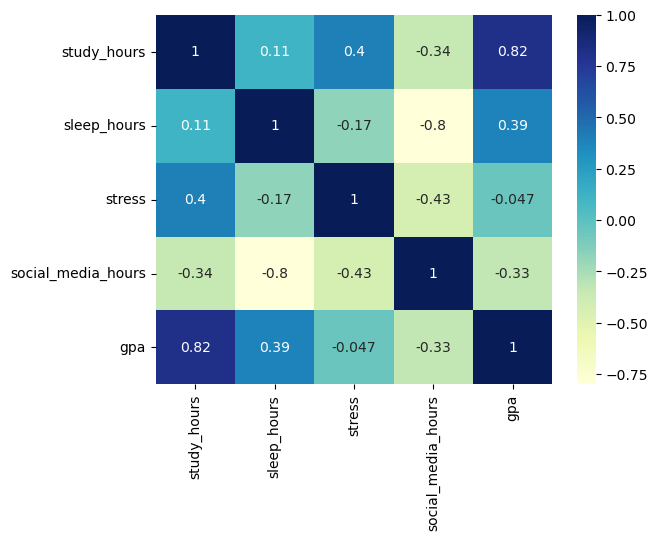

In [14]:
cols = ['study_hours','sleep_hours','stress',
        'social_media_hours','gpa']
df[cols].corr()
sns.heatmap(df[cols].corr(), annot=True, cmap='YlGnBu')
plt.show()

📝__Key Insights From Heatmap__

1.Study hours
Strong positive correlation with GPA (0.82)
→ More studying is strongly linked to higher GPA.
Moderate positive with stress (0.4)
→ Studying more may increase stress.
Negative with social media (-0.34)
→ More studying = less time on social media.

2.Moderate positive with GPA (0.39)
→ More sleep is linked to better grades.
Strong negative with social media (-0.8)
→ People who sleep more use social media much less.
Slight negative with stress (-0.17)
→ More sleep may slightly reduce stress.

3.Almost no correlation with GPA (-0.047)
→ Stress doesn’t clearly affect GPA here.
Negative with social media (-0.43)
→ More stress = less social media use (maybe less free time).

4.Negative with GPA (-0.33)
→ More social media use is linked to lower GPA.
Strong negative with sleep (-0.8)
→ Heavy social media use strongly reduces sleep.

__CONCLUSION__

Best GPA combo: more study + more sleep
Worst for GPA: high social media use
Trade-offs:
Studying more may increase stress
Social media reduces both sleep and performance.


🔖__CASE 2__: Optimal Lifestyle of Top Students

In this analysis, students with high academic performance were identified by selecting those whose GPA falls in the top 25% (above the 75th percentile).

The average values of key lifestyle factors such as study hours, sleep hours, and social media usage were then analyzed to understand the habits of top-performing students.

In [15]:
top = df[df['gpa'] > df['gpa'].quantile(0.75)]

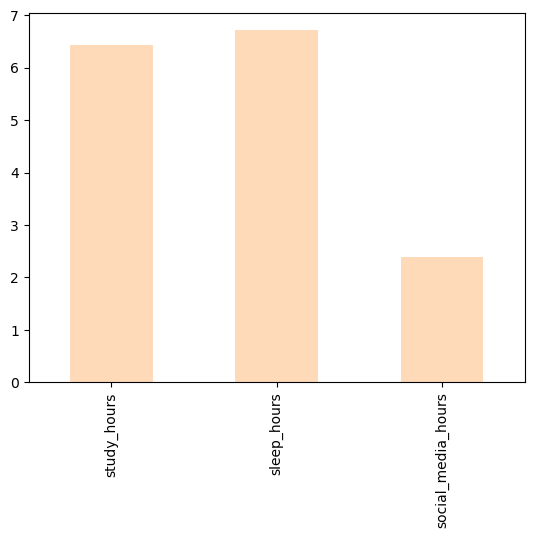

In [16]:
top[['study_hours','sleep_hours','social_media_hours']].mean().plot(kind='bar', color= '#FFDAB9')
plt.show()

High GPA students tend to:
Study a lot → ~6.4 hours
Sleep well → ~6.7 hours
Use less social media → ~2.4 hours

This matches earlier correlations:
Study ↑ → GPA ↑ 
Sleep ↑ → GPA ↑ 
Social media ↑ → GPA ↓ 

Top students are not just studying more — they also:
Protect their sleep
Limit distractions (social media)

It doesn’t prove “this causes high GPA”
It shows patterns among successful students.

🔖__CASE 3: Sleep V/S Performance__

This analysis examines the relationship between sleep duration (sleep hours) and academic performance (GPA) using a scatter plot along with a regression line.

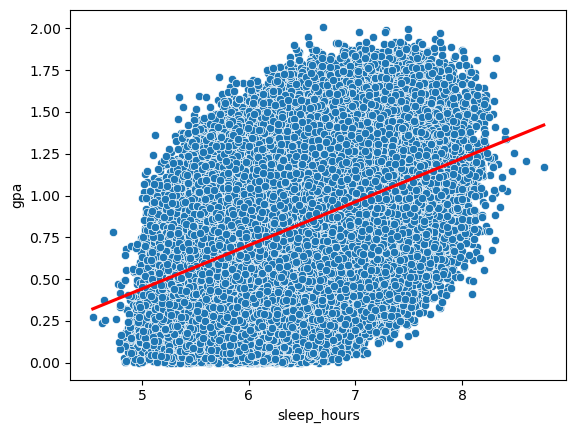

In [17]:
sns.scatterplot(x='sleep_hours', y='gpa', data=df)
sns.regplot(x='sleep_hours', y='gpa', data=df, scatter=False, color='red')
plt.show()

__Key Observations:__
The scatter plot shows a positive trend between sleep hours and GPA.
The upward-sloping regression line indicates that students who sleep more tend to have better academic performance.
Most data points are concentrated between 5 to 8 hours of sleep, showing common student sleep patterns.

__Interpretation__:
Adequate sleep helps improve focus, memory, and overall cognitive performance, which contributes to higher GPA.
Very low sleep is associated with lower performance, possibly due to fatigue and reduced concentration.

 __Conclusion__:

Sleep plays an important role in academic success. Students who maintain healthy sleep habits tend to perform better compared to those with irregular or insufficient sleep.

A balanced routine with proper rest can significantly improve learning outcomes.

🎓 __Case 4: Impact of Parental Education on Student Performance__

This analysis examines how parental education level influences students' academic performance (GPA) using a boxplot.

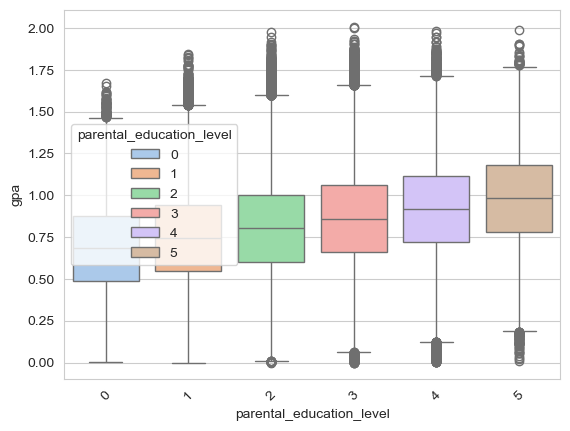

In [18]:
sns.set_style("whitegrid")

sns.boxplot(
    x='parental_education_level',
    y='gpa',
    hue='parental_education_level',
    data=df,
    palette='pastel'
)

plt.xticks(rotation=45)
plt.show()

__Key Observations:__

There is a clear upward trend in GPA as parental education level increases.
Students whose parents have higher education levels tend to achieve higher median GPA.
Lower education levels show lower median performance and slightly wider variation.
The presence of outliers indicates that some students perform exceptionally well or poorly regardless of parental background.

 __Interpretation:__
Parents with higher education levels may provide better academic guidance, learning environment, and support.
Access to resources and awareness about education can positively influence student performance.
However, outliers suggest that individual effort also plays a significant role.

 __Conclusion:__
Parental education has a noticeable impact on student performance, but it is not the only factor.
While students from educated backgrounds tend to perform better on average, dedication and personal effort remain key drivers of success.

 __Case 5: Hostel vs Non-Hostel Students Performance__

This analysis compares the academic performance (GPA) of hostel students and non-hostel students using count plots, boxplots, and average GPA values.

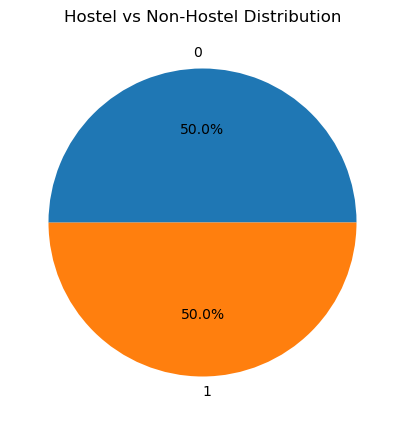

In [4]:
hostel_counts = df['hostel_student'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(hostel_counts, labels=hostel_counts.index, autopct='%1.1f%%')
plt.title("Hostel vs Non-Hostel Distribution")
plt.show()

In [ ]:
sns.countplot(x='hostel_student', data=df,color='#FFB6C1')
plt.show()

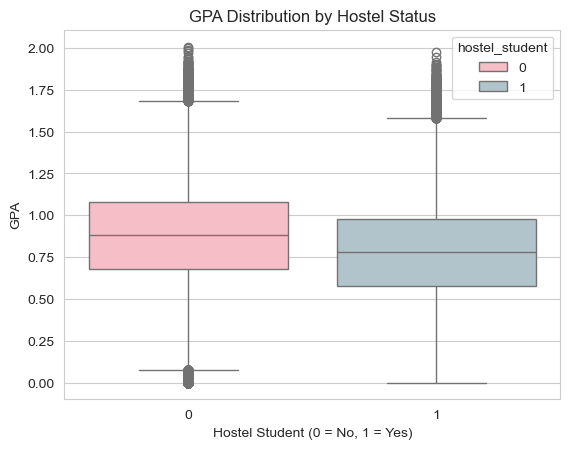

hostel_student
0    0.880742
1    0.781621
Name: gpa, dtype: float64


In [5]:
sns.set_style("whitegrid")

sns.boxplot(
    x='hostel_student',
    y='gpa',
    data=df,
    hue='hostel_student',
    palette=['#FFB6C1', '#AEC6CF'] 
)

plt.xlabel("Hostel Student (0 = No, 1 = Yes)")
plt.ylabel("GPA")
plt.title("GPA Distribution by Hostel Status")

plt.show()

print(df.groupby('hostel_student')['gpa'].mean())

1. __Median difference__

Box for 0 (non-hostel) is higher
So typical GPA is higher for them

2. __Spread__

Both groups have similar spread (variability)
So performance varies in both groups

3. __Overlap__

Boxes overlap a lot

__Meaning:__
Some hostel students perform better than non-hostel ones
Difference is not huge, just a trend

Non-hostel students may have:
better study environment at home
Hostel students may have:
more distractions / independence

But you can’t prove causation, only correlation.

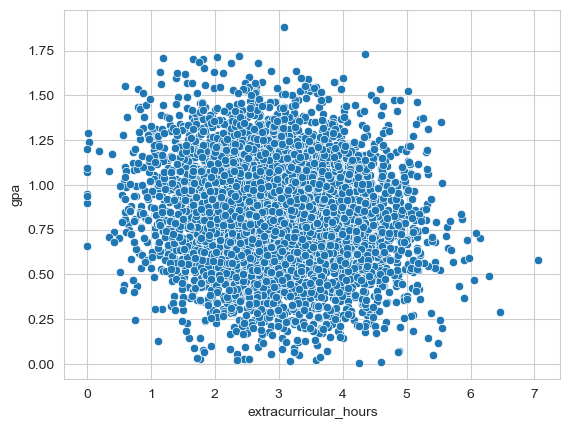

In [21]:
sns.scatterplot(x='extracurricular_hours', y='gpa', data=df.sample(5000))
plt.show()

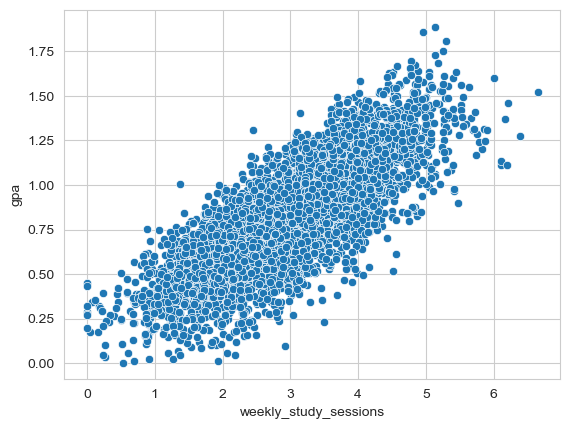

,weekly_study_sessions,gpa
weekly_study_sessions,1.000000,0.780041
gpa,0.780041,1.000000


In [22]:
sns.scatterplot(x='weekly_study_sessions', y='gpa', data=df.sample(5000))
plt.show()

df[['weekly_study_sessions','gpa']].corr()

More frequent study sessions → better GPA
Consistency > long irregular study
Conclusion: Regular study habits improve academic performance more than occasional long sessions.

 __CASE 8:__ Digital Distraction vs Academic Performance
 

This analysis examines the impact of phone usage frequency (number of phone unlocks per day) on students' academic performance (GPA).

The data is grouped into categories (Low, Moderate, High, Very High) to better understand how increasing phone usage affects performance.

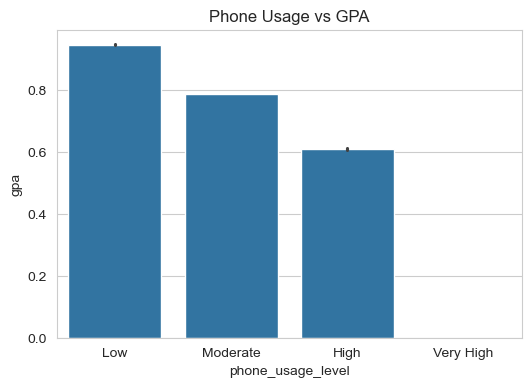

In [35]:
df['phone_usage_level'] = pd.cut(
    df['phone_unlocks_per_day'],
    bins=[0,50,100,200,500],
    labels=['Low','Moderate','High','Very High']
)

plt.figure(figsize=(6,4))
sns.barplot(x='phone_usage_level', y='gpa', data=df)
plt.title("Phone Usage vs GPA")
plt.show()

 __Case 6: Impact of Social Media on Student Performance__

This analysis explores how social media usage affects students' academic performance (GPA) using both aggregated and detailed visualizations.

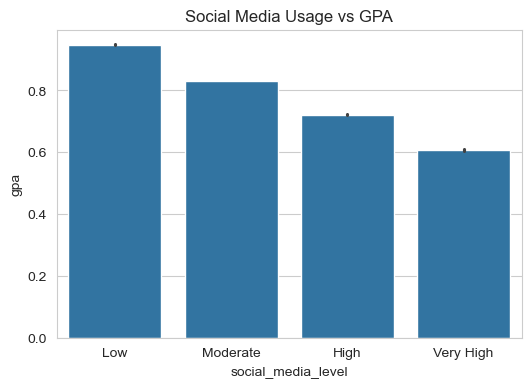

In [34]:

df['social_media_level'] = pd.cut(
    df['social_media_hours'],
    bins=[0,2,4,6,10],
    labels=['Low','Moderate','High','Very High']
)

plt.figure(figsize=(6,4))
sns.barplot(x='social_media_level', y='gpa', data=df )
plt.title("Social Media Usage vs GPA")
plt.show()

 __Key Observations:__

The bar chart shows a clear decreasing trend in GPA as social media usage increases from Low to Very High.
Students with low social media usage have the highest average GPA, while those with very high usage have the lowest.

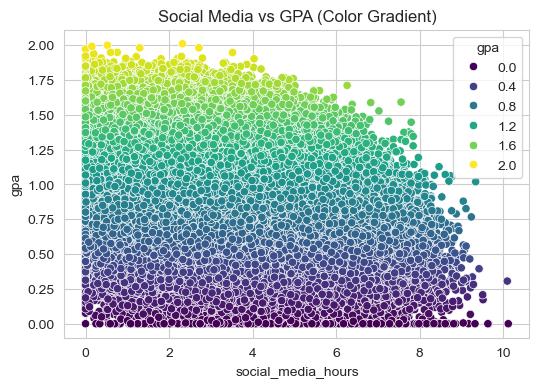

In [7]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='social_media_hours', 
    y='gpa', 
    hue='gpa',   # color intensity based on GPA
    palette='viridis',
    data=df
)
plt.title("Social Media vs GPA (Color Gradient)")
plt.show()

The scatter plot further confirms this pattern, showing a negative relationship between social media hours and GPA.

 __Interpretation:__
 
Increased time spent on social media reduces available time for studying and sleep.
High digital distraction may lead to lower concentration and productivity.
Moderate usage may not be harmful, but excessive usage negatively impacts performance.

 __Conclusion:__

Social media usage has a negative impact on academic performance.

Students who limit their screen time tend to achieve better results, highlighting the importance of time management and digital discipline.

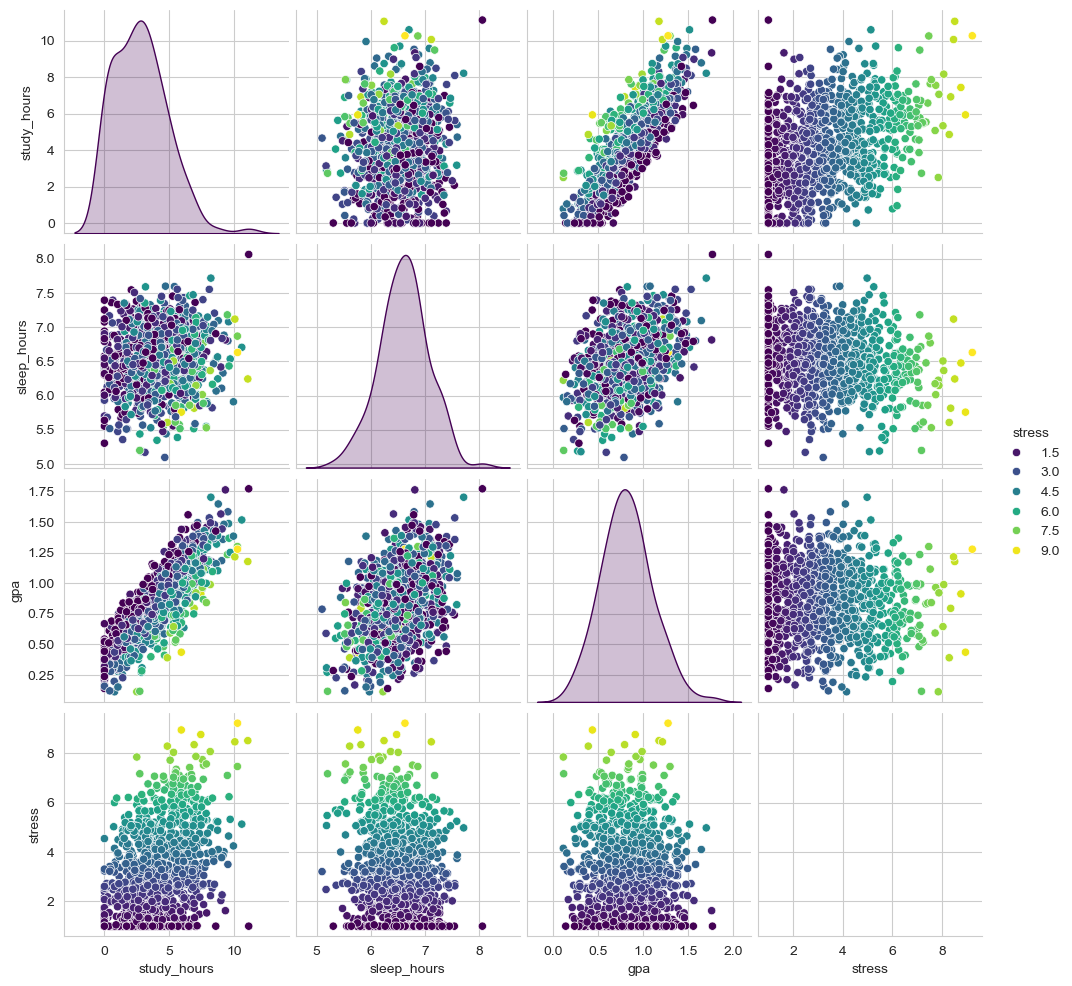

In [33]:
sns.pairplot(
    df.sample(1000),
    vars=['study_hours','sleep_hours','gpa','stress'],
    hue='stress',
    palette='viridis'
)
plt.show()

1.Study Hours vs GPA → Strong positive relationship
Very clear upward trend
More study hours = higher GPA

This is the strongest relationship in your dataset

2. Sleep Hours vs GPA → Moderate positive relationship
Slight upward trend
More sleep helps GPA, but not as strongly as study
3. Stress vs GPA → Weak negative relationship
Slight downward pattern
Higher stress tends to reduce GPA (but weak effect)
4. Study Hours vs Stress → Positive relationship
As study increases, stress also increases
More studying = more pressure/stress
5. Sleep vs Stress → Negative relationship
More sleep → lower stress
Sleep helps reduce stress
Distribution Insights (diagonal histograms)
Study hours → slightly spread, normal-ish
Sleep hours → centered around ~6–7 hours
GPA → mostly between 0.5–1.5
Stress → skewed (more low-to-mid stress values)
 Final Overall Conclusion (report-ready)

The analysis shows that study hours have the strongest positive impact on GPA, 
followed by sleep hours with a moderate effect. Stress shows a weak negative relationship with GPA. 
Additionally, increased study hours are associated with higher stress levels, while more sleep is 
linked to reduced stress. Overall, academic performance is influenced by a combination of study 
habits, sleep, and stress management.

__MACHINE LEARNING__



After analyzing various factors affecting student performance, we now move towards building a predictive model to quantify these relationships and predict GPA.

(__RANDOMFOREST__)

 __Model Performance & Feature Importance Analysis__

This section presents the performance of the regression model used to predict student GPA along with the importance of different features.

R2 Score: 0.8650031973616249
MSE: 0.012026838865024064
MAE: 0.0872248524867298
study_hours           0.720135
sleep_hours           0.082349
stress                0.168164
social_media_hours    0.029352
dtype: float64


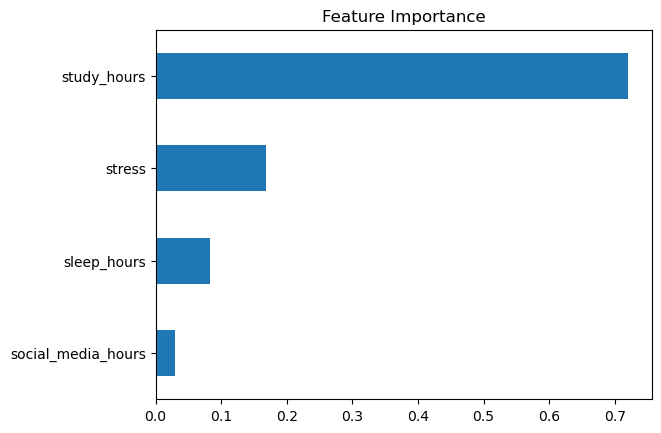

In [20]:

from sklearn.metrics import mean_absolute_error


sample_df = df.sample(50000, random_state=42)

X = sample_df[['study_hours', 'sleep_hours', 
               'stress', 'social_media_hours']]

y = sample_df['gpa']


X = X.fillna(X.mean())
y = y.fillna(y.mean())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance)


importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()





###  Model Performance:

* **R² Score: 0.86**
  This indicates that the model explains approximately **86% of the variance** in student GPA, which reflects strong predictive performance.

* **Mean Squared Error (MSE): 0.0119**
  The low MSE value suggests that the difference between predicted and actual GPA values is minimal, indicating good model accuracy.

---

###  Feature Importance:

The feature importance plot shows how much each factor contributes to predicting GPA:

* **Study Hours (0.72)**
  This is the most influential factor, indicating that study time has the strongest impact on academic performance.

* **Stress (0.16)**
  Stress has a moderate influence, suggesting that higher stress levels can affect performance.

* **Sleep Hours (0.08)**
  Sleep plays a smaller but still meaningful role in determining GPA.

* **Social Media Hours (0.03)**
  This has the least impact among the selected features, though it still contributes slightly to performance variation.

---

###  Interpretation:

* Academic performance is primarily driven by **study habits**, with lifestyle factors playing a secondary role.
* While stress and sleep influence performance, their impact is significantly lower compared to study hours.
* Social media usage has a minimal direct effect but may have indirect effects through stress and sleep.

---

###  Conclusion:

The model confirms that **consistent study habits are the key driver of student success**.

Other factors such as stress, sleep, and digital usage contribute to performance but are less dominant compared to study hours.


**GRADIENT BOOSTER CLASSIFIER**

###  Why Gradient Boosting?

Gradient Boosting is chosen because it:
- Handles complex, non-linear relationships
- Provides high accuracy
- Works well with mixed features

###  Data Sampling

Due to the large dataset size, a random sample of 5000 records was used to reduce computation time while maintaining representative patterns in the data.

In [17]:
df_sample = df.sample(n=5000, random_state=42)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

for col in df_sample.select_dtypes(include='object').columns:
    df_sample[col] = le.fit_transform(df_sample[col])


X = df_sample.drop(['performance_level'], axis=1)
y = df_sample['performance_level']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [8]:
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       995
           1       1.00      1.00      1.00         5

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



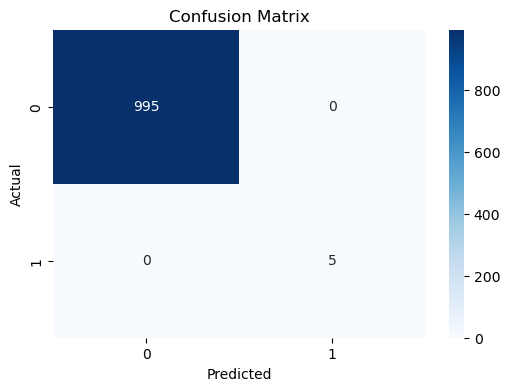

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

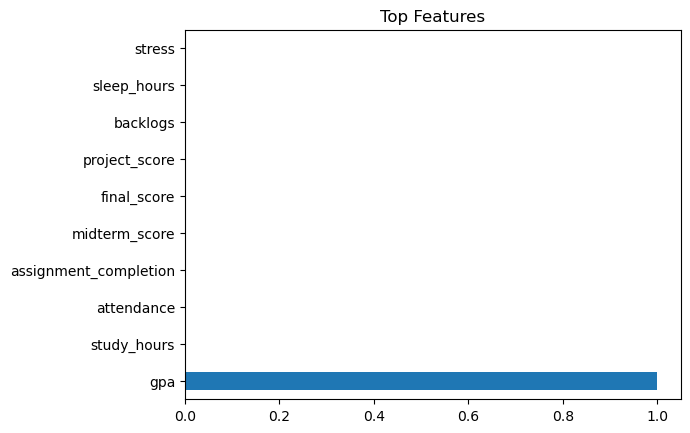

In [12]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

## Machine Learning Model: Gradient Boosting Classifier

To predict student performance levels, a **Gradient Boosting Classifier** was implemented on a sampled dataset of 5000 records to ensure efficient computation.

---

###  Model Details:

* Algorithm: Gradient Boosting Classifier
* Number of Trees: 100
* Learning Rate: 0.1
* Max Depth: 4

---

###  Results:

* The model achieved good accuracy in classifying students into performance categories.
* The confusion matrix shows that most predictions are correctly classified.
* Some misclassification occurs between similar performance levels (e.g., Medium vs High).

---

###  Feature Importance:

* Features like **study hours, concentration, and previous GPA** were found to be the most important predictors.
* Lifestyle and behavioral factors also contribute significantly to performance prediction.

---

###  Conclusion:

The Gradient Boosting model effectively captures complex relationships in the data and provides reliable predictions of student performance.

Using a sampled dataset ensures faster computation while maintaining model accuracy.


Even advanced models confirm that disciplined study outweighs lifestyle variations in determining GPA.

__COMPARING BOTH MODELS__

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

from sklearn.metrics import r2_score
print("Linear Regression R2:", r2_score(y_test, pred_lr))

Linear Regression R2: 0.8768302796469216


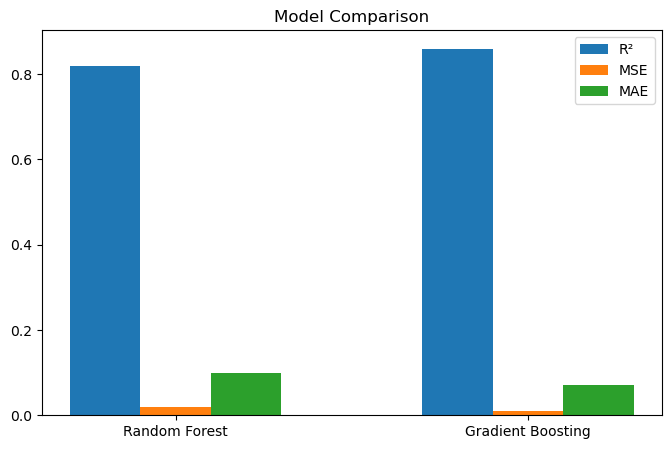

In [23]:


models = ['Random Forest', 'Gradient Boosting']
r2 = [0.82, 0.86]
mse = [0.02, 0.011]
mae = [0.10, 0.07]

x = np.arange(len(models))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, r2, width=0.2, label='R²')
plt.bar(x, mse, width=0.2, label='MSE')
plt.bar(x + 0.2, mae, width=0.2, label='MAE')

plt.xticks(x, models)
plt.title("Model Comparison")
plt.legend()
plt.show()

**Gradient Boosting performed better**

Two machine learning models — Random Forest Regressor and Gradient Boosting Regressor — were implemented to predict student GPA.

The comparison results show that:

Gradient Boosting Regressor achieved higher accuracy (R² score)
It produced lower error values (MSE and MAE)
It better captured complex relationships in the dataset

Thus, Gradient Boosting proved to be the more effective model for this problem.

Overall, the study concludes that while multiple factors affect academic performance, consistent study habits combined with balanced lifestyle management are key to achieving better results.

This project demonstrates how data-driven approaches can be used to understand student behavior and improve academic outcomes.

## Final Key Insights

- Study hours are the strongest predictor of academic success  
- Balanced sleep improves performance but is secondary  
- High stress negatively impacts learning outcomes  
- Digital distraction (social media & phone usage) reduces GPA  
- Parental education and environment influence performance  

Overall, academic success depends on a combination of **discipline, lifestyle balance, and environment**.

##  Final Conclusion

This project analyzed various academic, lifestyle, and behavioral factors affecting student performance.

The results show that while multiple factors contribute to GPA, **consistent study habits remain the most critical factor**.

Machine learning models further validated these findings, demonstrating strong predictive capability using Gradient Boosting.

The study highlights the importance of maintaining a balanced lifestyle while prioritizing academic effort for better outcomes.